<a href="https://colab.research.google.com/github/Prianka-Mukhopadhyay/voyage-analytics/blob/main/Voyage_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**VOYAGE ANALYTICS**
### **Group Members**
####Prianka Mukhopadhyay
####Aayush Kaul
####Sri Vaishnavi Thalloju
####Om Mane


#**PROBLEM STATEMENTS**
####Build a regression model to predict the prices of a flight acccurately.
####Deploy a classification model to acccurately identify user's gender.
####Build a recommendation model to provide hotel suggestions based on user preferrences and historical data.
####Build a streamlit application to display insights using travel recommendation model.


**Github Link:** https://github.com/Prianka-Mukhopadhyay/voyage-analytics

In [1]:
 # import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install streamlit

In [2]:
# import necessary functions
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# import data
flights = pd.read_csv('flights.csv')
users = pd.read_csv('users.csv')
hotels = pd.read_csv('hotels.csv')

In [4]:
# Null value traetment
flights.isnull().sum()

,0
travelCode,0
userCode,0
from,0
to,0
flightType,0
price,0
time,0
distance,0
agency,0
date,0


In [5]:
users.isnull().sum()

,0
code,0
company,0
name,0
gender,0
age,0


In [6]:
hotels.isnull().sum()

,0
travelCode,0
userCode,0
name,0
place,0
days,0
price,0
total,0
date,0


In [7]:
# Merge dataset for recommendations
users_flights = users.merge(flights, left_on='code', right_on='userCode')

In [8]:
# Separate x and y for price prediction.
x= flights.drop(['price'],axis=1)
y= flights['price']

In [9]:
# Separate cat and con from x
x_cat= x.select_dtypes(object)
x_con= x.select_dtypes(np.number)

In [10]:
# Check combined cat and con from dataframe.
x_cat.head()

,from,to,flightType,agency,date
0,Recife (PE),Florianopolis (SC),firstClass,FlyingDrops,09/26/2019
1,Florianopolis (SC),Recife (PE),firstClass,FlyingDrops,09/30/2019
2,Brasilia (DF),Florianopolis (SC),firstClass,CloudFy,10/03/2019
3,Florianopolis (SC),Brasilia (DF),firstClass,CloudFy,10/04/2019
4,Aracaju (SE),Salvador (BH),firstClass,CloudFy,10/10/2019


In [11]:
x_con.head()

,travelCode,userCode,time,distance
0,0,0,1.76,676.53
1,0,0,1.76,676.53
2,1,0,1.66,637.56
3,1,0,1.66,637.56
4,2,0,2.16,830.86


In [12]:
x = pd.concat([x_cat, x_con], axis=1)
x.head()

,from,to,flightType,agency,date,travelCode,userCode,time,distance
0,Recife (PE),Florianopolis (SC),firstClass,FlyingDrops,09/26/2019,0,0,1.76,676.53
1,Florianopolis (SC),Recife (PE),firstClass,FlyingDrops,09/30/2019,0,0,1.76,676.53
2,Brasilia (DF),Florianopolis (SC),firstClass,CloudFy,10/03/2019,1,0,1.66,637.56
3,Florianopolis (SC),Brasilia (DF),firstClass,CloudFy,10/04/2019,1,0,1.66,637.56
4,Aracaju (SE),Salvador (BH),firstClass,CloudFy,10/10/2019,2,0,2.16,830.86


In [13]:
# Preprocess data
# Feature Encoding
le = LabelEncoder()
x_cat = x_cat.apply(le.fit_transform)

In [14]:
# Feature Scaling
ss= StandardScaler()
x_con = pd.DataFrame(ss.fit_transform(x_con), columns=x_con.columns)

In [15]:
# Remove outliers and reset the index
out =[]
for i in x_con.columns:
  o1 = [(x_con[i]< -3) | (x_con[i]>3)]
  out.append(o1)
out

[[0         False
  1         False
  2         False
  3         False
  4         False
            ...  
  271883    False
  271884    False
  271885    False
  271886    False
  271887    False
  Name: travelCode, Length: 271888, dtype: bool],
 [0         False
  1         False
  2         False
  3         False
  4         False
            ...  
  271883    False
  271884    False
  271885    False
  271886    False
  271887    False
  Name: userCode, Length: 271888, dtype: bool],
 [0         False
  1         False
  2         False
  3         False
  4         False
            ...  
  271883    False
  271884    False
  271885    False
  271886    False
  271887    False
  Name: time, Length: 271888, dtype: bool],
 [0         False
  1         False
  2         False
  3         False
  4         False
            ...  
  271883    False
  271884    False
  271885    False
  271886    False
  271887    False
  Name: distance, Length: 271888, dtype: bool]]

In [16]:
# Extract the boolean Series from the nested list structure in 'out'
outlier_masks = [mask[0] for mask in out]

# Combine the boolean masks to find rows where at least one column is an outlier
# This creates a DataFrame of boolean masks and then checks if any column is True for each row
combined_outlier_mask = pd.concat(outlier_masks, axis=1).any(axis=1)

# Get the indices of the rows identified as outliers
outliers = x_con.index[combined_outlier_mask].tolist()

outliers # Display the list of outlier indices

[]

In [17]:
x.shape

(271888, 9)

In [18]:
y.shape

(271888,)

In [19]:
import statsmodels.api as sm

In [20]:
#Feature Selection

# First, ensure 'x' is the correctly preprocessed data by combining encoded x_cat and scaled x_con
x_for_modeling = pd.concat([x_cat, x_con], axis=1)

# To resolve the NameError, we need an initial model to determine the first 'c' to drop.
# Perform an initial split and fit to define an 'initial_model'
xtrain_init, _, ytrain_init, _ = train_test_split(x_for_modeling, y, test_size=0.2, random_state=21)

# Add a constant for the OLS model (sm was imported in a previous cell)
X_train_const_init = sm.add_constant(xtrain_init)

# Fit an initial OLS model to get the p-values for the first drop
initial_model = sm.OLS(ytrain_init, X_train_const_init).fit()

# Now, 'initial_model' is defined and we can get the first 'c' to drop
c = initial_model.pvalues.sort_values().index[-1] # last column to drop based on initial model

print(f"Initial model R-squared adjusted: {round(initial_model.rsquared_adj, 3)}")
print(f"Feature with highest p-value (to drop first): '{c}'")

# Drop that column from the features used for the *next* split and model fitting
x = x_for_modeling.drop(labels=c, axis=1)

# Now, split the data again with the modified 'x'
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=21)

# Add constant and fit the OLS model with the reduced feature set
ols=sm.OLS(ytrain,sm.add_constant(xtrain))
model=ols.fit() # 'model' is now defined for the rest of the cell

score=round(model.rsquared_adj,3)

# This 'c' will be the next column to drop based on the newly fitted 'model'
c=model.pvalues.sort_values().index[-1]

print('Next column to drop (if continuing the process):', c)
print('R-squared adjusted after first feature drop:', score)

Initial model R-squared adjusted: 0.499
Feature with highest p-value (to drop first): 'date'
Next column to drop (if continuing the process): agency
R-squared adjusted after first feature drop: 0.499


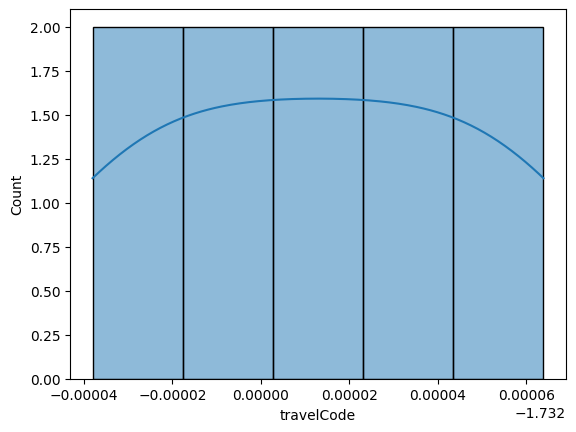

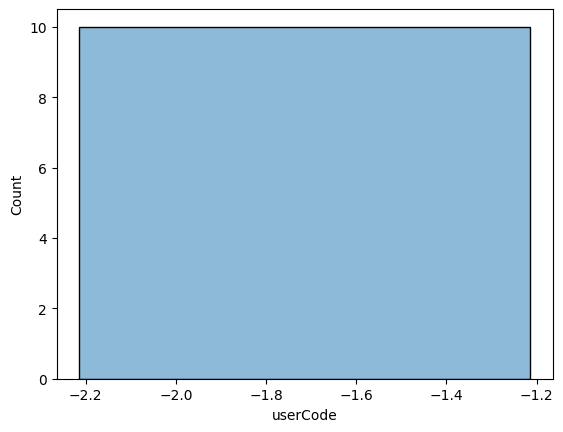

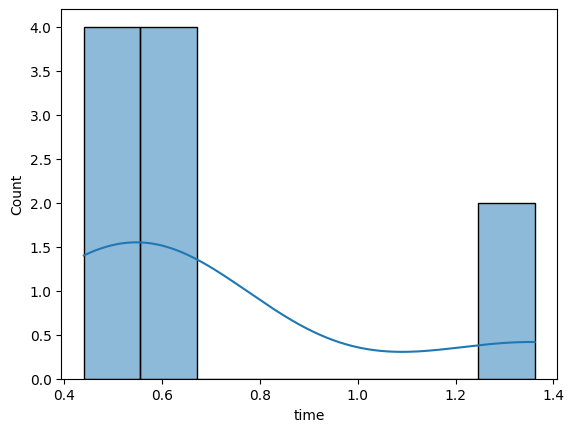

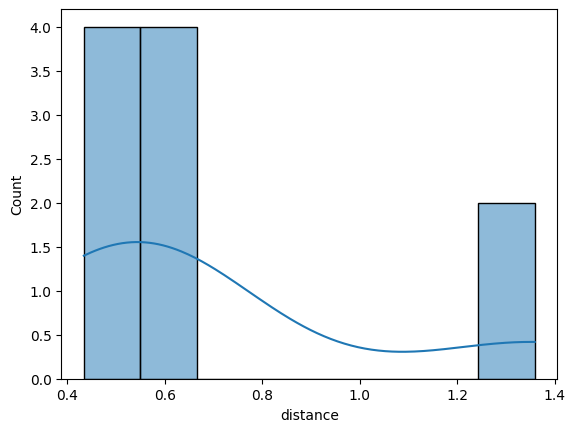

In [21]:
# Visualisation
for i in x_con.columns:
  sns.histplot(data =x.head(10), x=str(i), kde =True)
  plt.show()

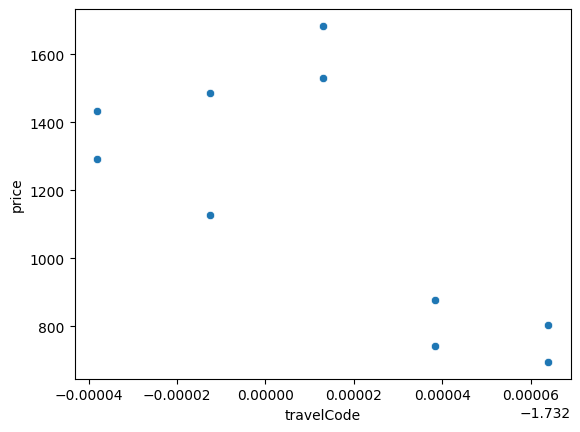

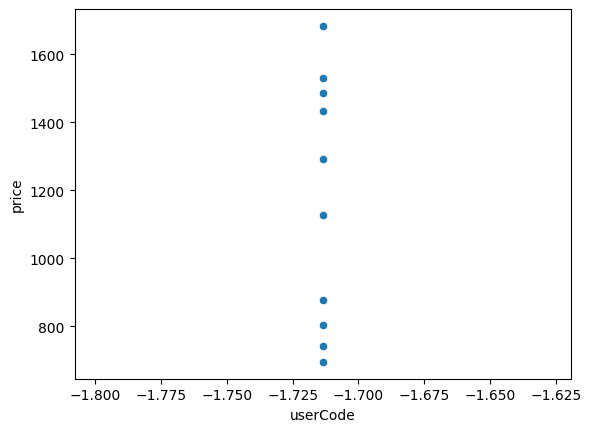

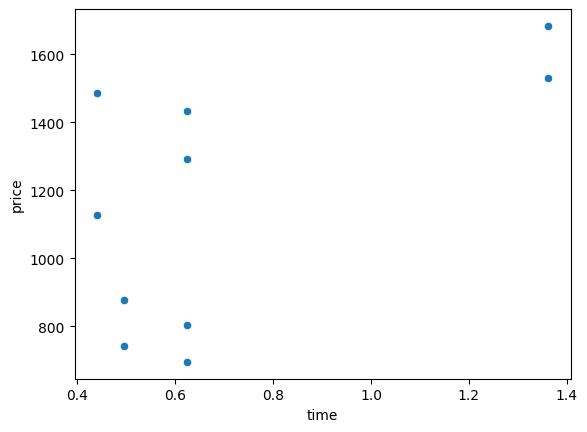

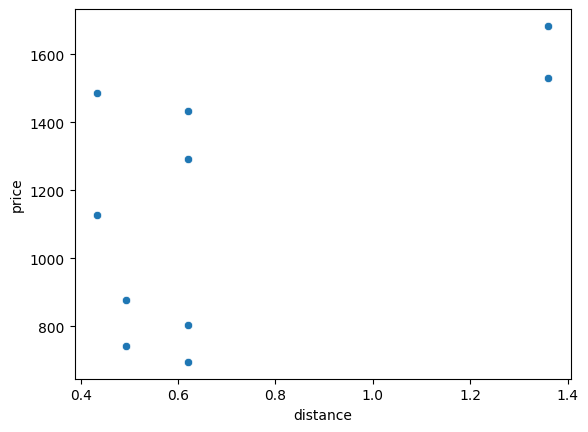

In [22]:
plot_df = pd.concat([x, y], axis=1)
for i in x_con.columns:
  sns.scatterplot(data = plot_df.head(10), x=str(i), y='price')
  plt.show()

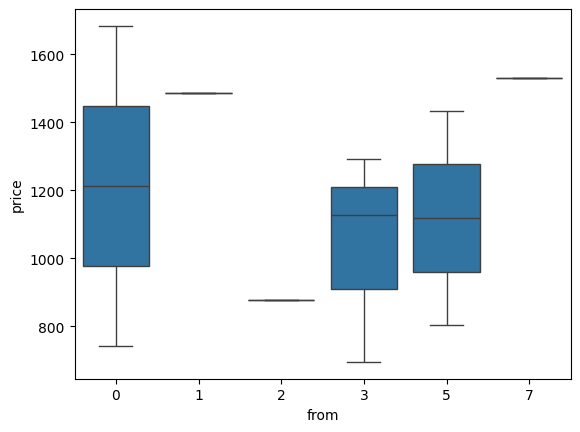

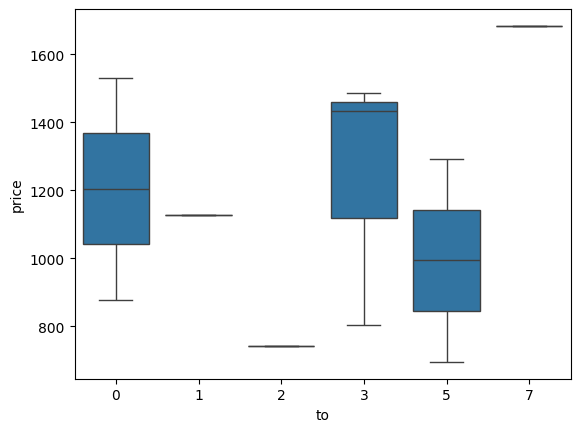

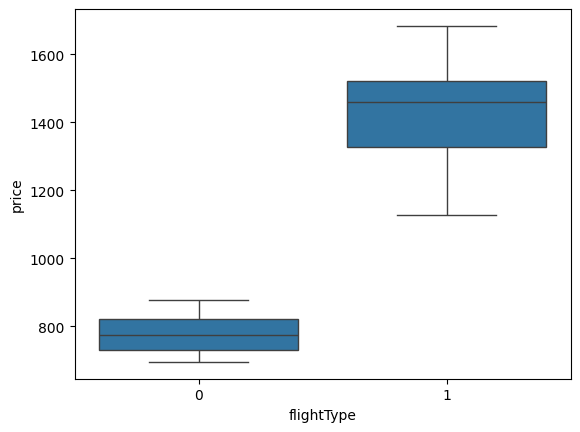

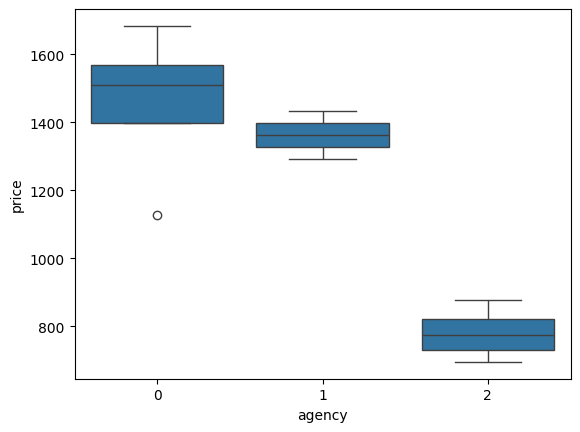

In [23]:
plot_df = pd.concat([x, y], axis=1)
# Filter x_cat.columns to only include columns that are present in the current x DataFrame
categorical_cols_for_plotting = [col for col in x_cat.columns if col in x.columns]

for i in categorical_cols_for_plotting:
  sns.boxplot(data = plot_df.head(10), x=str(i), y='price')
  plt.show()

In [24]:
#Apply XG Boost
from xgboost import XGBRegressor

In [25]:
xgb = XGBRegressor()
model = xgb.fit(xtrain,ytrain)

In [26]:
ypred_train = model.predict(xtrain)
ypred_test = model.predict(xtest)

In [27]:
print("Training accuracy is :", model.score(xtrain,ytrain))
print("Testing accuracy is :", model.score(xtest,ytest))

Training accuracy is : 0.9999467088967116
Testing accuracy is : 0.9999449099624322


In [28]:
# Install MLFLOW
!pip install mlflow

In [29]:
import mlflow
import mlflow.xgboost
mlflow.set_experiment("voyage-analytics-models")

<Experiment: artifact_location='/content/mlruns/1', creation_time=1774467702136, experiment_id='1', last_update_time=1774467702136, lifecycle_stage='active', name='voyage-analytics-models', tags={}, workspace='default'>

In [30]:
mlflow.autolog()  # Auto-logs everything
with mlflow.start_run(run_name="flight-price-xgb"):
    model = xgb.fit(xtrain, ytrain)
    ypred_test = model.predict(xtest)
    # Custom metrics if needed
    from sklearn.metrics import r2_score, mean_squared_error
    r2 = r2_score(ytest, ypred_test)
    mse = mean_squared_error(ytest, ypred_test)
    rmse = np.sqrt(mse) # Calculate RMSE manually
    mlflow.log_metric("r2_test", r2)
    mlflow.log_metric("rmse_test", rmse)
mlflow.end_run()

2026/03/25 20:03:35 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/03/25 20:03:35 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2026/03/25 20:03:35 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
2026/03/25 20:03:35 WARNING mlflow.spark: With Pyspark >= 3.2, PYSPARK_PIN_THREAD environment variable must be set to false for Spark datasource autologging to work.
2026/03/25 20:03:35 INFO mlflow.tracking.fluent: Autologging successfully enabled for pyspark.
2026/03/25 20:03:37 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid th

In [31]:
# CLASSIFICATION MODEL

In [32]:
# Separate x and y for gender classification.
x = users.drop(['gender'], axis=1)
y = users['gender']

In [33]:
users['gender'].value_counts()

,count
gender,
male,452
female,448
none,440


In [34]:
# Separate cat and con from X
cat=[]
con=[]
for i in x.columns:
  if x[i].dtypes==object:
    cat.append(i)
  else:
    con.append(i)

In [35]:
xcat=x[cat]
xcon=x[con]

In [36]:
for i in xcat.columns:
  xcat[i]=le.fit_transform(xcat[i])

/tmp/ipykernel_7897/1454737557.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xcat[i]=le.fit_transform(xcat[i])
/tmp/ipykernel_7897/1454737557.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xcat[i]=le.fit_transform(xcat[i])


In [37]:
xcon=pd.DataFrame(ss.fit_transform(xcon),columns=con)

In [38]:
x=xcon.join(xcat)
x.head()

,code,age,company,name
0,-1.730759,-1.690057,0,1121
1,-1.728174,-0.446370,0,653
2,-1.725588,0.408665,0,1324
3,-1.723003,-1.534596,0,1013
4,-1.720418,0.097743,0,997


In [39]:
# Label Encode Y since  it is a categorical output with related categoric outputs.
y=le.fit_transform(y)
y=pd.DataFrame(y,columns=['gender'])
y.head()

,gender
0,1
1,1
2,0
3,0
4,0


In [40]:
# Remove outliers and reset the index.
out=[]
for i in xcon.columns:
  o1=xcon[(xcon[i]<-3)|(xcon[i]>3)].index
  out.extend(o1)
out=list(set(out))

In [41]:
print(out)

[]


In [42]:
x.shape

(1340, 4)

In [43]:
y.shape

(1340, 1)

In [44]:
#  Reduce biasedness of data using SMOTE
from imblearn.over_sampling import SMOTE

In [45]:
x_smote,y_smote=SMOTE().fit_resample(x,y)

2026/03/25 20:03:59 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'a26a7379e5c8472fa31d3d72492cc022', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/03/25 20:03:59 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2026/03/25 20:03:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/25 20:03:59 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/03/25 20:04:06 WARNI

In [46]:
y_smote.value_counts()

,count
gender,
0,452
1,452
2,452


In [47]:
y_smote=pd.DataFrame(y_smote,columns=['gender'])
y

,gender
0,1
1,1
2,0
3,0
4,0
...,...
1335,1
1336,0
1337,1
1338,0


In [48]:
# Perform train test split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [49]:
#  Feature Selection
# Sequential Feature Selection
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier

In [50]:
# Define the model RFC
clf = RandomForestClassifier(n_estimators=10, random_state=42) # Added random_state for reproducibility
# Initialize SFS with the classifier for feature selection for the classification task
sfs=SequentialFeatureSelector(clf,n_features_to_select='auto',direction='forward',cv=4)
sfs.fit(x_smote,y_smote.values.ravel()) # .values.ravel() to handle (n,1) vs (n,) shape mismatch


2026/03/25 20:04:10 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '3df241ef854e4999bd785a09f8044b72', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/03/25 20:04:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/25 20:04:15 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '143e4542c5074208bda6e3e692d7bd54', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/03/25 20:04:15 WARNING mlflow.sklearn: Saving scikit-learn models in the

SequentialFeatureSelector(cv=4,
                          estimator=RandomForestClassifier(n_estimators=10,
                                                           random_state=42))

In [51]:
print("Selected features are:",sfs.get_support(indices=True))

Selected features are: [1 3]


In [52]:
# Error Evaluation
# Extract selected features for training and testing based on sfs.get_support()
selected_features_indices = sfs.get_support(indices=True)

# Prepare data with selected features
x_smote_selected = x_smote.iloc[:, selected_features_indices]
xtest_selected = xtest.iloc[:, selected_features_indices]

# Train the RandomForestClassifier (clf) with the SMOTE'd data and selected features
clf.fit(x_smote_selected, y_smote.values.ravel())

# Make predictions for the classification task
ypred_train_clf = clf.predict(x_smote_selected)
ypred_test_clf = clf.predict(xtest_selected)

2026/03/25 20:06:29 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'e1e9a6d6d34b41acabeb6ac719a4da4f', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/03/25 20:06:29 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https:/

In [53]:
# Evaluate the classification model using the correct predictions and true labels
print("Training accuracy score is",accuracy_score(y_smote.values.ravel(), ypred_train_clf))
print("Testing accuracy score is",accuracy_score(ytest.values.ravel(), ypred_test_clf))
print('***')
print("Training confusion matrix is")
print(confusion_matrix(y_smote.values.ravel(), ypred_train_clf))
print("Testing confusion matrix is")
print(confusion_matrix(ytest.values.ravel(), ypred_test_clf))

Training accuracy score is 0.9646017699115044
Testing accuracy score is 0.9776119402985075
***
Training confusion matrix is
[[440   7   5]
 [  4 446   2]
 [ 12  18 422]]
Testing confusion matrix is
[[88  1  0]
 [ 0 93  1]
 [ 3  1 81]]


In [54]:
from sklearn.metrics import f1_score

In [55]:
with mlflow.start_run(run_name="user-gender-rf"):
    # Using the SMOTE'd and selected features for training
    clf.fit(x_smote_selected, y_smote.values.ravel())
    mlflow.sklearn.log_model(clf, "gender_model")
    # Logging f1_score for the test set
    mlflow.log_metric("f1_test", f1_score(ytest.values.ravel(), clf.predict(xtest_selected), average='weighted'))

2026/03/25 20:06:33 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/03/25 20:06:33 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils

In [56]:
# Recommendation Model

In [57]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

In [58]:
# Feature Engineering
user_hotel_matrix = hotels.pivot_table(
    index='userCode',
    columns='name',
    values='total',
    aggfunc='sum'
).fillna(0)

In [59]:
from sklearn.metrics.pairwise import cosine_similarity
user_similarity = cosine_similarity(user_hotel_matrix)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_hotel_matrix.index,
    columns=user_hotel_matrix.index
)

In [60]:
def recommend_hotels(user_id):

    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:6]

    similar_users_data = user_hotel_matrix.loc[similar_users.index]

    recommended_hotels = similar_users_data.sum().sort_values(ascending=False)

    already_visited = user_hotel_matrix.loc[user_id]
    recommended_hotels = recommended_hotels[already_visited == 0]

    return recommended_hotels.head(5)

In [61]:
def recommend_by_place(place):
    filtered = df[df['place'] == place]
    return filtered.sort_values(by='total', ascending=False)[['name', 'place', 'total']].drop_duplicates().head(5)

In [62]:
def hybrid_recommendation(user_id):

    # Step 1: collaborative
    collab = recommend_hotels(user_id).index.tolist()

    # Step 2: user's preferred place
    user_places = df[df['userCode'] == user_id]['place'].mode()[0]

    content = df[df['place'] == user_places]['name'].unique().tolist()

    # combine
    final = list(set(collab + content))

    return final[:5]

In [63]:
mlflow.set_experiment("Travel_Recommendation_Model")

<Experiment: artifact_location='/content/mlruns/2', creation_time=1774467853472, experiment_id='2', last_update_time=1774467853472, lifecycle_stage='active', name='Travel_Recommendation_Model', tags={}, workspace='default'>

In [64]:
import mlflow.pyfunc

class HybridRecommenderModel(mlflow.pyfunc.PythonModel):

    def load_context(self, context):
        # Load the clean hotels data from artifact
        self.hotels_df = pd.read_csv(context.artifacts["data"])

        # Re-create user_hotel_matrix
        self.user_hotel_matrix = self.hotels_df.pivot_table(
            index='userCode',
            columns='name',
            values='total',
            aggfunc='sum'
        ).fillna(0)

        # Re-create user_similarity_df
        # Check if user_hotel_matrix is not empty before calculating similarity
        if not self.user_hotel_matrix.empty:
            self.user_similarity = cosine_similarity(self.user_hotel_matrix)
            self.user_similarity_df = pd.DataFrame(
                self.user_similarity,
                index=self.user_hotel_matrix.index,
                columns=self.user_hotel_matrix.index
            )
        else:
            self.user_similarity_df = pd.DataFrame() # Empty DataFrame if no data

    def _recommend_hotels(self, user_id):
        # Handle cases where user_id might not be in the matrix or similarity df is empty
        if self.user_similarity_df.empty or user_id not in self.user_similarity_df.columns:
            return pd.Series(dtype=object) # Return empty series if user not found or no data

        similar_users = self.user_similarity_df[user_id].sort_values(ascending=False)[1:6]

        # Filter out users that might not be in the matrix (though unlikely if user_id is from original data)
        similar_users_in_matrix = similar_users.index.intersection(self.user_hotel_matrix.index)
        if similar_users_in_matrix.empty:
            return pd.Series(dtype=object)

        similar_users_data = self.user_hotel_matrix.loc[similar_users_in_matrix]

        recommended_hotels = similar_users_data.sum().sort_values(ascending=False)

        # Ensure already_visited is based on the correct user_id in the matrix
        if user_id in self.user_hotel_matrix.index:
            already_visited = self.user_hotel_matrix.loc[user_id]
            # Only recommend hotels not already visited by the user
            recommended_hotels = recommended_hotels[already_visited == 0]
        else:
            # If user has no history, recommend top hotels from similar users
            pass # recommended_hotels already contains these

        return recommended_hotels.head(5)

    def _recommend_by_place(self, place):
        filtered = self.hotels_df[self.hotels_df['place'] == place]
        return filtered.sort_values(by='total', ascending=False)[['name', 'place', 'total']].drop_duplicates().head(5)

    def predict(self, context, model_input):
        user_id = model_input['userCode'].iloc[0] # Assuming model_input is a DataFrame with 'userCode'

        # Step 1: collaborative filtering recommendations
        collab_recs = self._recommend_hotels(user_id)
        collab_hotel_names = collab_recs.index.tolist()

        # Step 2: content-based recommendations (user's preferred place)
        user_history = self.hotels_df[self.hotels_df['userCode'] == user_id]
        if not user_history.empty:
            user_preferred_place = user_history['place'].mode()
            if not user_preferred_place.empty:
                user_preferred_place = user_preferred_place[0]
                content_recs = self.hotels_df[self.hotels_df['place'] == user_preferred_place]['name'].unique().tolist()
            else:
                content_recs = []
        else:
            content_recs = [] # No history for content-based

        # Combine and ensure uniqueness, then return top 5
        final_recommendations = list(set(collab_hotel_names + content_recs))

        return final_recommendations[:5]

/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [65]:
with mlflow.start_run() as run:
    global recommender_model_run_id
    recommender_model_run_id = run.info.run_id

    # Save dataset as artifact
    hotels.to_csv("hotels_clean.csv", index=False)

    # Log parameters
    mlflow.log_param("model_type", "Hybrid Collaborative + Content")
    mlflow.log_param("similarity_metric", "cosine")
    mlflow.log_param("input_data", "userCode + hotel history")

    # Log basic metrics
    mlflow.log_metric("num_users", hotels['userCode'].nunique())
    mlflow.log_metric("num_hotels", hotels['name'].nunique())
    mlflow.log_metric("avg_bookings_per_user", hotels.groupby('userCode').size().mean())

    # Log model
    mlflow.pyfunc.log_model(
        artifact_path="recommender_model",
        python_model=HybridRecommenderModel(),
        artifacts={"data": "hotels_clean.csv"}
    )

2026/03/25 20:06:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 20:06:42 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


In [66]:
# Using the programmatically retrieved run ID
model = mlflow.pyfunc.load_model(f"runs:/{recommender_model_run_id}/recommender_model")

In [67]:
import pandas as pd

test_input = pd.DataFrame({'userCode': [101]})

model.predict(test_input)

['Hotel BP', 'Hotel Z', 'Hotel K']

In [68]:
# Model creation for all the 3.
import joblib

In [69]:
# Regression
joblib.dump(model, 'model_price.pkl')
print("model_price.pkl saved")

model_price.pkl saved


In [70]:
# Classification
joblib.dump(clf, 'model_gender.pkl')
print("model_gender.pkl saved")

model_gender.pkl saved


In [71]:
# Recommendation
joblib.dump(model, 'model_hybrid.pkl')
print("model_hybrid.pkl saved")

model_hybrid.pkl saved


In [72]:
import os
print(os.listdir())

['.config', 'model_price.pkl', 'mlflow.db', 'model_hybrid.pkl', 'Voyage_Analytics_fixed.ipynb', 'drive', 'hotels_clean.csv', 'model_gender.pkl', 'hotels.csv', 'users.csv', 'mlruns', 'flights.csv', 'Voyage_Analytics.ipynb', 'sample_data']


In [75]:
import nbformat
file = "Voyage_Analytics.ipynb"

nb = nbformat.read(file, as_version=4)

#  Remove top-level widgets
if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

#  Remove cell-level metadata (THIS IS WHAT YOU MISSED)
for cell in nb.cells:
    if "metadata" in cell and "widgets" in cell["metadata"]:
        del cell["metadata"]["widgets"]

nbformat.write(nb, "cleaned_notebook.ipynb")